In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [2]:
train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')


In [3]:
print(train.shape, test.shape)

(1460, 81) (1459, 80)


<Axes: >

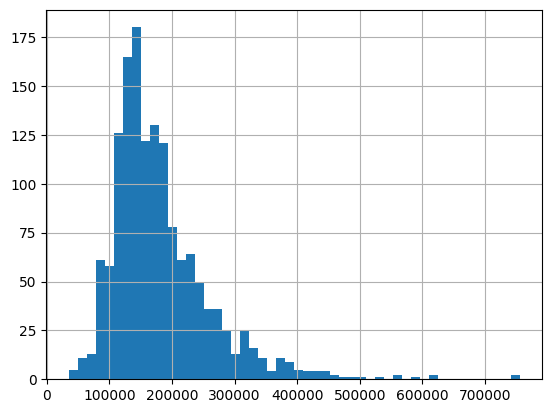

In [5]:
train['SalePrice'].describe()
train['SalePrice'].hist(bins=50)

In [6]:
train.head()
train.shape
train.info()
train.describe()
train.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [11]:
missing = train.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [40]:
numeric_cols = train.select_dtypes(include=[np.number])
correlations = numeric_cols.corr()['SalePrice'].sort_values(ascending=False)
print(correlations.head(15))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


In [9]:
train.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [12]:
pd.get_dummies(missing)

,1,8,37,38,81,259,690,872,1179,1369,1406,1453
PoolQC,False,False,False,False,False,False,False,False,False,False,False,True
MiscFeature,False,False,False,False,False,False,False,False,False,False,True,False
Alley,False,False,False,False,False,False,False,False,False,True,False,False
Fence,False,False,False,False,False,False,False,False,True,False,False,False
MasVnrType,False,False,False,False,False,False,False,True,False,False,False,False
FireplaceQu,False,False,False,False,False,False,True,False,False,False,False,False
LotFrontage,False,False,False,False,False,True,False,False,False,False,False,False
GarageQual,False,False,False,False,True,False,False,False,False,False,False,False
GarageFinish,False,False,False,False,True,False,False,False,False,False,False,False
GarageType,False,False,False,False,True,False,False,False,False,False,False,False


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

y = train.SalePrice
X = train[['OverallQual','PoolQC','Alley','BsmtQual','FireplaceQu','GarageQual','LotFrontage','1stFlrSF']]

cat_cols = ['PoolQC', 'Alley', 'BsmtQual', 'FireplaceQu', 'GarageQual']
X = pd.get_dummies(X, columns=cat_cols)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_valid.head())
print(predictions)

[137950.5        367066.04333333 127406.34666667 123782.83333333
 326622.52333333]


In [8]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

val_preds = model.predict(X_valid)   # no .head(), predict all rows

print("MAE:", mean_absolute_error(y_valid, val_preds))
print("RMSLE:", np.sqrt(mean_squared_error(np.log(y_valid), np.log(val_preds))))

MAE: 24597.175973375302
RMSLE: 0.19394684339710494


In [10]:
features = [c for c in X.columns]  # after get_dummies
X_test = test[['OverallQual','PoolQC','Alley','BsmtQual','FireplaceQu','GarageQual','LotFrontage','1stFlrSF']]  # use the same list as your X
X_test = pd.get_dummies(X_test, columns=cat_cols)
X_test = X_test.reindex(columns=X.columns, fill_value=0)
test_preds = model.predict(X_test)

submission = pd.DataFrame({"Id": test.Id, "SalePrice": test_preds})
submission.to_csv("submission.csv", index=False)
print(submission)

        Id      SalePrice
0     1461  139426.540000
1     1462  155608.166667
2     1463  147160.623333
3     1464  129770.666667
4     1465  216438.666667
...    ...            ...
1454  2915   76739.888889
1455  2916   87286.958333
1456  2917  182909.203333
1457  2918  131691.223333
1458  2919  223549.483333

[1459 rows x 2 columns]
